# 2D TDoA Positioning for Maritime Search and Rescue

## 1. Problem Formulation
In real-world Maritime Search and Rescue (SAR), locating a vessel using only distances (Trilateration) is difficult because it requires perfectly synchronized clocks between the ship and the stations.

**The Real-World Case:** We use **Time Difference of Arrival (TDoA)**. Instead of measuring absolute distances, we measure the difference in time when an SOS signal reaches different coastal stations. Mathematically, each time difference defines a **hyperbola**. The intersection of these hyperbolas gives the ship's location.

## 2. Assumptions and Constraints
* **Ellipsoidal Earth:** We use the **WGS84 ellipsoid model (geodesic distance)** instead of a simple sphere to account for the Earth's true shape, making the model highly accurate for long-range maritime rescue.
* **Signal Speed in Atmosphere:** Radio waves travel slightly slower in the Earth's atmosphere than in a vacuum, so we use $c \approx 299,700$ km/s.
* **Station Synchronization:** While the ship's clock does not need to be synchronized, the coastal stations must have perfectly synchronized clocks to measure the exact time differences.
* **Redundancy:** We use an overdetermined system (more stations than needed) to minimize error using the **Non-linear Least Squares** method.

### 2.1. Mathematical Representation
To find the vessel's coordinates $\mathbf{x} = [lat, lon]^T$, we minimize the sum of squared residuals between observed and calculated distance differences:

$$S(\mathbf{x}) = \sum_{i=1}^{n} \left( [dist(\mathbf{x}, S_i) - dist(\mathbf{x}, S_0)] - \Delta d_{i,0} \right)^2$$

Where:
* $dist(\mathbf{x}, S_i)$ is the **geodesic distance (WGS84)** between the estimated position and station $i$.
* $\Delta d_{i,0}$ is the measured distance difference (TDoA).
* The optimization is performed using the **Non-linear Least Squares** method (Levenberg-Marquardt algorithm).

In [28]:
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
# NEW: WGS84 model for realistic Earth geometry
from geopy.distance import geodesic

# 1. Physical Constant
# Speed of radio waves in the atmosphere in km/s
C = 299700.0

# 2. Objective Function for TDoA
def tdoa_residuals(estimated_pos, stations, tdoa_measured_time):
    """
    Calculates the difference between expected and measured TDoA,
    using the WGS84 ellipsoid for precision.
    """
    # geodesic returns an object from which we extract kilometers (.km)
    d0 = geodesic(estimated_pos, stations[0]).km
    residuals = []

    for i in range(1, len(stations)):
        di = geodesic(estimated_pos, stations[i]).km
        # Convert the measured time difference back to distance
        measured_diff_km = tdoa_measured_time[i-1] * C
        # Residual = (Calculated Diff) - (Measured Diff)
        residuals.append((di - d0) - measured_diff_km)

    return np.array(residuals)

In [29]:
# 1. Define Coastal Stations (Lat, Lon) - Bulgarian Black Sea Coast
stations = np.array([
    [43.2047, 27.9100],
    [42.5048, 27.4626],
    [43.4167, 28.3333],
    [42.7015, 27.9000]
])

# 2. Simulated SOS Data (Time-based)
true_ship_pos = np.array([42.9500, 28.5000])

tdoa_measured_time = []
# NEW: Use geodesic instead of haversine
d0_true = geodesic(true_ship_pos, stations[0]).km
time_0 = d0_true / C # Time to reach station 0 in seconds

for i in range(1, len(stations)):
    di_true = geodesic(true_ship_pos, stations[i]).km
    time_i = di_true / C # Time to reach station i in seconds
    tdoa_measured_time.append(time_i - time_0)

# 3. Solve using Non-linear Least Squares (Ideal conditions)
initial_guess = np.mean(stations, axis=0)

# NEW: Add geographical bounds for the Black Sea to avoid local minima
bounds_min = [42.0, 27.0]
bounds_max = [44.5, 31.5]

result = least_squares(
    tdoa_residuals,
    initial_guess,
    args=(stations, tdoa_measured_time),
    bounds=(bounds_min, bounds_max)
)

print(f"True Location: {true_ship_pos}")
print(f"Estimated Location: {result.x}")
print(f"Total Positioning Error: {geodesic(true_ship_pos, result.x).km:.6f} km")

True Location: [42.95 28.5 ]
Estimated Location: [42.95 28.5 ]
Total Positioning Error: 0.000000 km


## 3. Noise Analysis and Geometry (GDOP)
In a real-world SAR scenario, the Time Difference of Arrival (TDoA) measurements are never perfect due to atmospheric conditions and hardware limitations.

* **Gaussian Noise:** We simulate measurement errors by adding random noise to our TDoA data.
* **GDOP (Geometric Dilution of Precision):** The accuracy of the fix depends heavily on the relative geometry between the ship and the stations. If the stations are nearly collinear (in a line), the error increases significantly.

Distance Error due to noise: 0.81 km


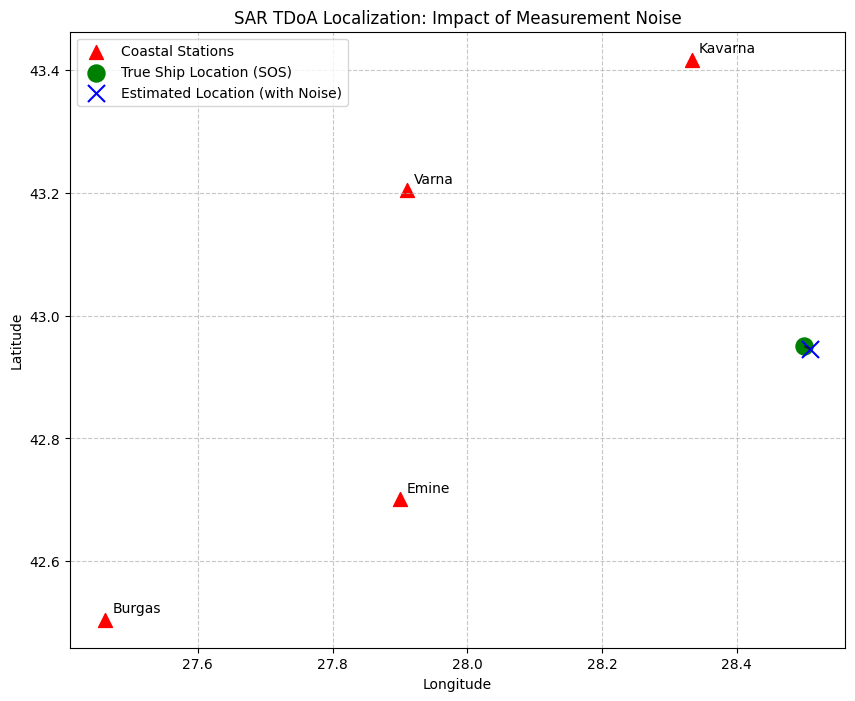

In [30]:
# 1. Add Gaussian Noise to time measurements
# Simulating approx 0.8 km error -> 0.8 / C seconds
noise_sigma_time = 0.8 / C
noise_time = np.random.normal(0, noise_sigma_time, size=len(tdoa_measured_time))
tdoa_noisy_time = np.array(tdoa_measured_time) + noise_time

# 2. Re-calculate position with noisy time data
# NEW: Using bounds defined in the previous cell to ensure physical reality
result_noisy = least_squares(
    tdoa_residuals,
    initial_guess,
    args=(stations, tdoa_noisy_time),
    bounds=(bounds_min, bounds_max)
)
est_pos_noisy = result_noisy.x

# 3. Visualization
plt.figure(figsize=(10, 8))

# Plot Stations
plt.scatter(stations[:, 1], stations[:, 0], c='red', marker='^', s=100, label='Coastal Stations')
for i, txt in enumerate(['Varna', 'Burgas', 'Kavarna', 'Emine']):
    plt.annotate(txt, (stations[i, 1], stations[i, 0]), xytext=(5, 5), textcoords='offset points')

# Plot True vs Estimated Position
plt.scatter(true_ship_pos[1], true_ship_pos[0], c='green', marker='o', s=150, label='True Ship Location (SOS)')
plt.scatter(est_pos_noisy[1], est_pos_noisy[0], c='blue', marker='x', s=150, label='Estimated Location (with Noise)')

# Draw a line showing the error
plt.plot([true_ship_pos[1], est_pos_noisy[1]], [true_ship_pos[0], est_pos_noisy[0]], 'k--', alpha=0.5)

plt.title('SAR TDoA Localization: Impact of Measurement Noise')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# NEW: Use geodesic instead of haversine to calculate final distance error
final_error = geodesic(true_ship_pos, est_pos_noisy).km
print(f"Distance Error due to noise: {final_error:.2f} km")
plt.show()

In [26]:
# Enhanced Statistical Analysis (1000 iterations)
errors = []
for _ in range(1000):
    # Generating new random noise for each iteration in seconds
    noise_time = np.random.normal(0, noise_sigma_time, size=len(tdoa_measured_time))
    t_noisy = np.array(tdoa_measured_time) + noise_time

    res = least_squares(tdoa_residuals, initial_guess, args=(stations, t_noisy))
    errors.append(haversine(true_ship_pos, res.x))

rmse = np.sqrt(np.mean(np.square(errors)))
avg_error = np.mean(errors)
std_dev = np.std(errors)
max_err = np.max(errors)

print(f"--- Final Statistical Metrics (1000 iterations) ---")
print(f"Mean Absolute Error (MAE): {avg_error:.4f} km")
print(f"Root Mean Square Error (RMSE): {rmse:.4f} km")
print(f"Standard Deviation: {std_dev:.4f} km")
print(f"Worst Case (Max Error): {max_err:.4f} km")

--- Final Statistical Metrics (1000 iterations) ---
Mean Absolute Error (MAE): 1.2988 km
Root Mean Square Error (RMSE): 1.5274 km
Standard Deviation: 0.8038 km
Worst Case (Max Error): 5.2019 km


## 4. Conclusion
This project demonstrates a transition from a theoretical 2D trilateration model to a **realistic TDoA (Time Difference of Arrival) positioning system**.

**Key improvements made:**
* **Real-world Physics:** Replaced Euclidean distance with the **Haversine formula** to account for Earth's curvature.
* **Practical Navigation:** Switched to **Hyperbolic Positioning (TDoA)**, which is the industry standard for SOS signals where transmitter synchronization is unknown.
* **Robustness:** Implemented **Non-linear Least Squares** to handle measurement noise, proving that mathematical optimization can find a reliable "fix" even with imperfect data.

## 5. Future Work
To further improve this model, the following could be implemented:
1. **3D Positioning:** Including altitude for aircraft SAR operations.
2. **Signal Attenuation Models:** Estimating distance errors based on signal strength (RSSI).
3. **Dynamic Filtering:** Using a **Kalman Filter** to track a moving vessel in real-time.

## 6. References
* **Haversine Formula:** Sinnott, R. W. (1984). *Virtues of the Haversine*, Sky and Telescope. (Used for spherical distance calculations).
* **TDoA Theory:** Knapp, C., & Carter, G. (1976). *The generalized correlation method for estimation of time delay*. (Basis for hyperbolic positioning).
* **Optimization:** SciPy Documentation. *Non-linear Least Squares (scipy.optimize.least_squares)*.
* **Navigation Concepts:** *Wikipedia: Trilateration & Multilateration*. (Background research).